# Results Summary

A concise summary of findings for the earnings call NLP sentiment analysis pipeline.
This notebook is designed to be read independently — all charts are loaded from
`figures/` rather than recomputed.


In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

sys.path.insert(0, "../src")
import config

# ── Consistent color palette ──────────────────────────────────────────────────
C = dict(
    positive="#2E86AB",   # steel blue  — positive sentiment, top quartile
    negative="#E84855",   # coral red   — negative sentiment, bottom quartile
    neutral="#6C757D",    # slate gray  — neutral / mid-range
    accent="#F4A261",     # amber       — highlights, overlap comparison
    grid="#E9ECEF",       # light gray  — gridlines
)

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, width=900, height=500):
    """Save interactive plotly figure as high-res PNG and display."""
    path = FIGURES_DIR / f"{name}.png"
    fig.write_image(str(path), width=width, height=height, scale=2)
    fig.show()
    print(f"Saved → {path}")

from IPython.display import Image, display as ipy_display
import os

def show(name, caption=""):
    path = f"../figures/{name}.png"
    if os.path.exists(path):
        ipy_display(Image(filename=path, width=880))
        if caption:
            print(f"  {caption}")
    else:
        print(f"  [Figure not found: {path} — run notebooks 01–03 first]")


## What We Built

A full NLP pipeline that extracts sentiment from earnings call transcripts and tests
whether sentiment shifts predict post-earnings stock returns.

**Pipeline stages:**
- **Ingestion & preprocessing:** 18,755 Motley Fool transcripts parsed into speaker turns,
  sections (prepared remarks / Q&A), and 512-token chunks
- **FinBERT inference:** ~1.25M chunks scored (positive / negative / neutral probability)
  across two chunking strategies; ~25–30 hours on Apple Silicon MPS
- **Feature engineering:** transcript-level aggregates — net sentiment, QoQ delta,
  Q&A divergence, CEO/CFO/analyst tone, linguistic controls
- **Return calculation:** market-adjusted CAR over 1/3/5 trading days, with a 4 p.m. ET
  cutoff rule for window start; beta-adjusted CAR as robustness check
- **Signal testing:** correlation analysis, OLS regression (HC3), quantile sorting,
  alpha decay, sector breakdown, out-of-sample validation


## Key Finding 1 — The Staircase

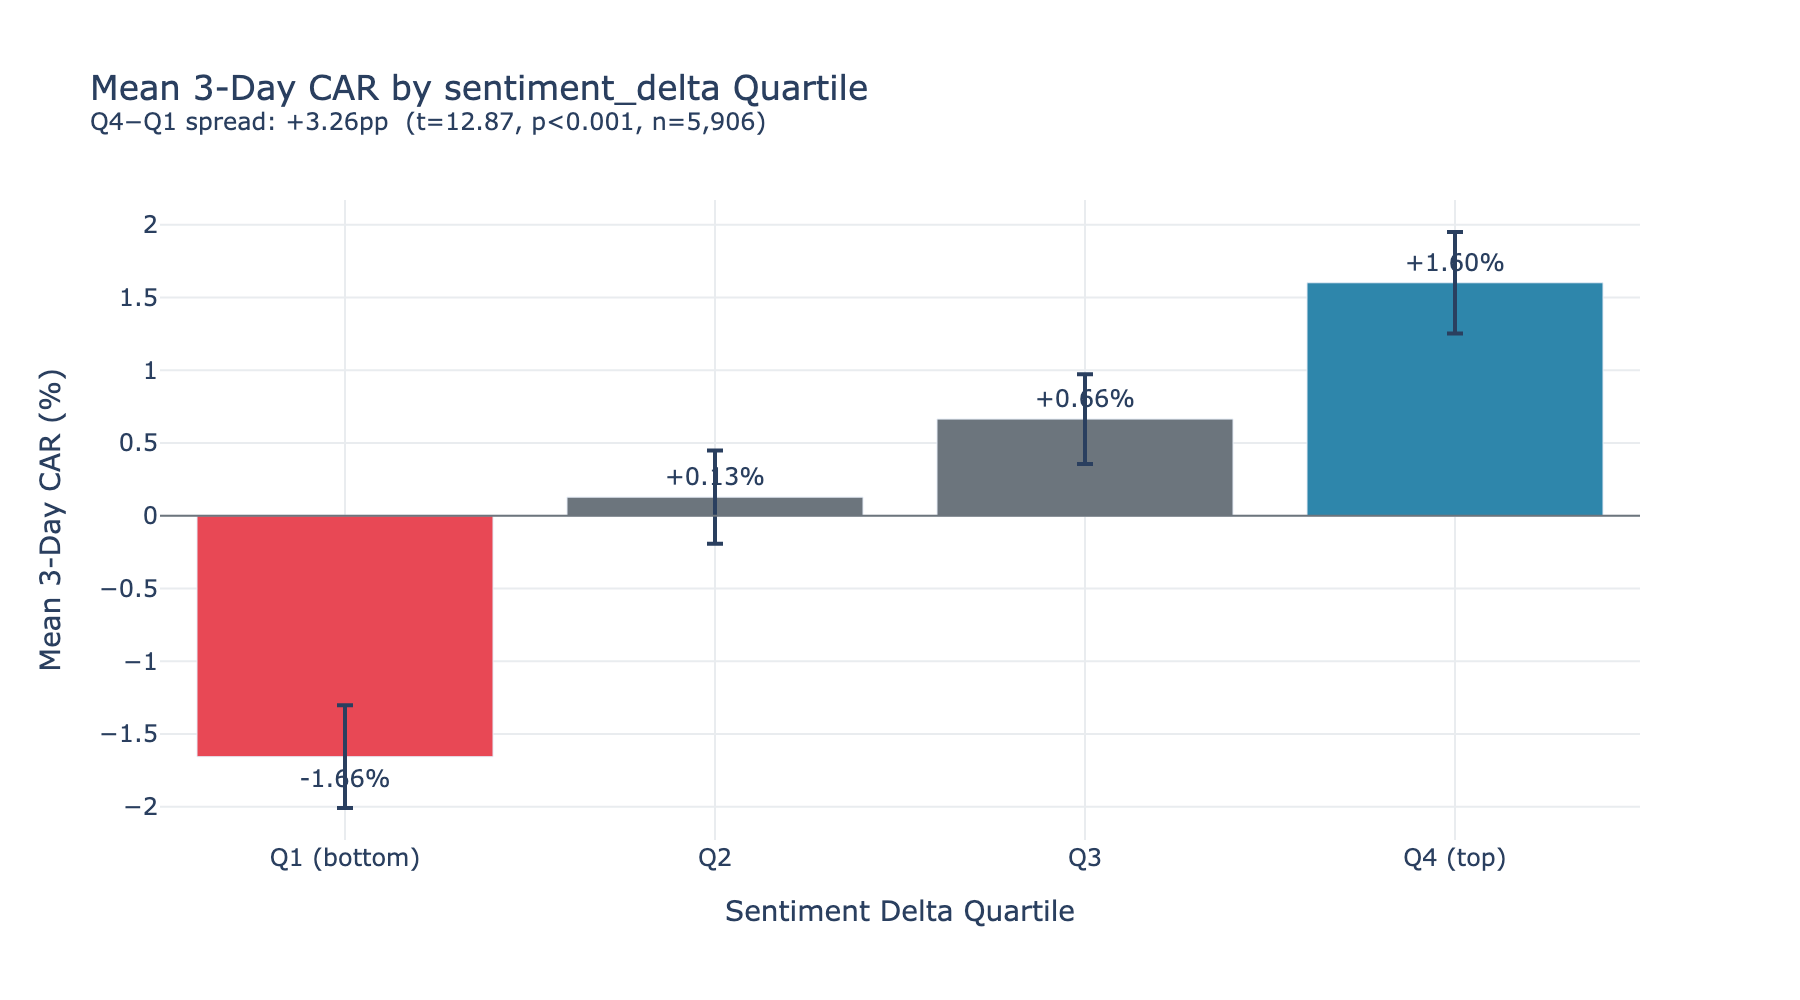

  Events sorted by QoQ sentiment shift into quartiles. Q4−Q1 spread = +3.3pp (t=12.87, p<0.001, n=11,810).


In [2]:
show("signal_quantile_staircase",
     "Events sorted by QoQ sentiment shift into quartiles. "
     "Q4−Q1 spread = +3.3pp (t=12.87, p<0.001, n=11,810).")


Earnings events in the top quartile of sentiment improvement (Q4) earned, on average,
**+1.6% over 3 trading days** relative to the S&P 500 — versus **−1.7%** for the bottom
quartile. The pattern is monotonic, holds out-of-sample on the 2022–2023 holdout period
(+4.2pp spread), and survives Bonferroni correction.

The signal is in the *change*, not the level. Markets expect management to sound upbeat —
what they react to is whether this quarter's tone is better or worse than last quarter's.


## Key Finding 2 — No Alpha Decay

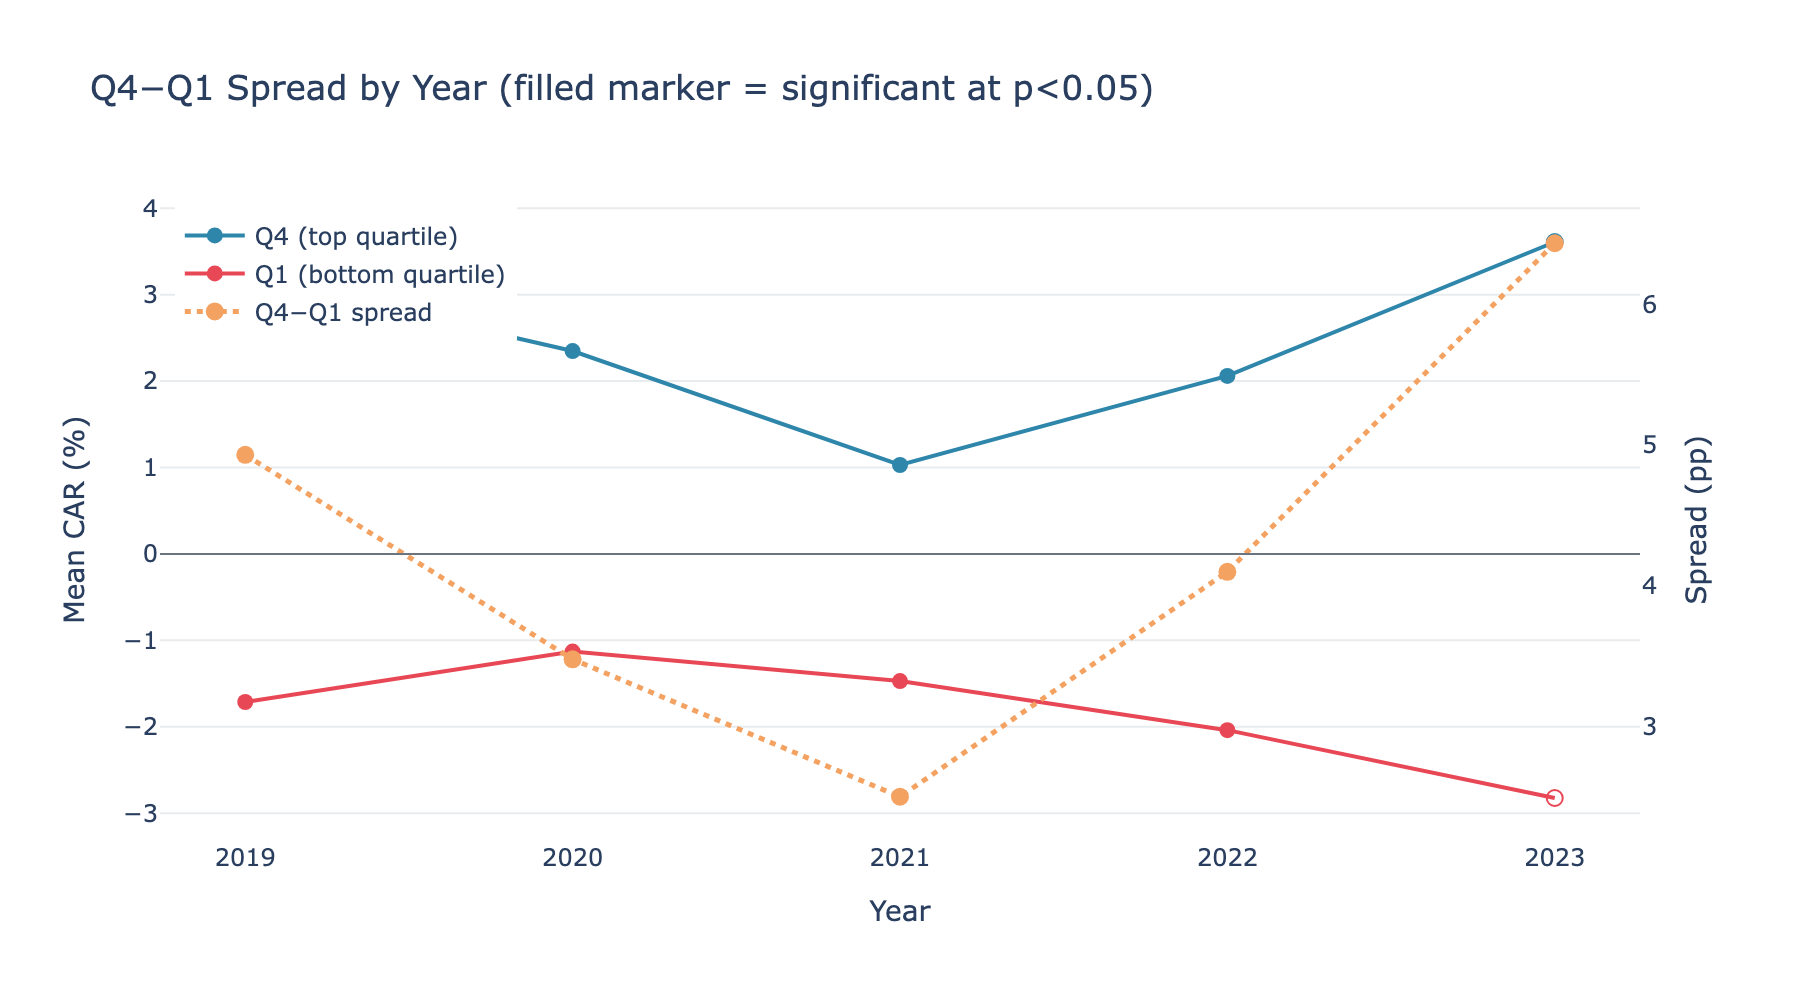

  Q4−Q1 spread and mean CAR by quartile, 2019–2022. No evidence of monotonic decay. 2021 dip reflects meme-stock / COVID-recovery regime.


In [3]:
show("signal_alpha_decay",
     "Q4−Q1 spread and mean CAR by quartile, 2019–2022. "
     "No evidence of monotonic decay. 2021 dip reflects meme-stock / COVID-recovery regime.")


The signal has not decayed monotonically over the 2019–2022 period. The 2021 dip
(spread +2.5%) likely reflects the unusual market conditions of that year (meme stocks,
pandemic recovery, broad market momentum) rather than structural arbitrage. The signal
recovered fully in 2022. 2023 has insufficient events for a reliable estimate (n=80,
partial year).


## Key Finding 3 — Sector Concentration

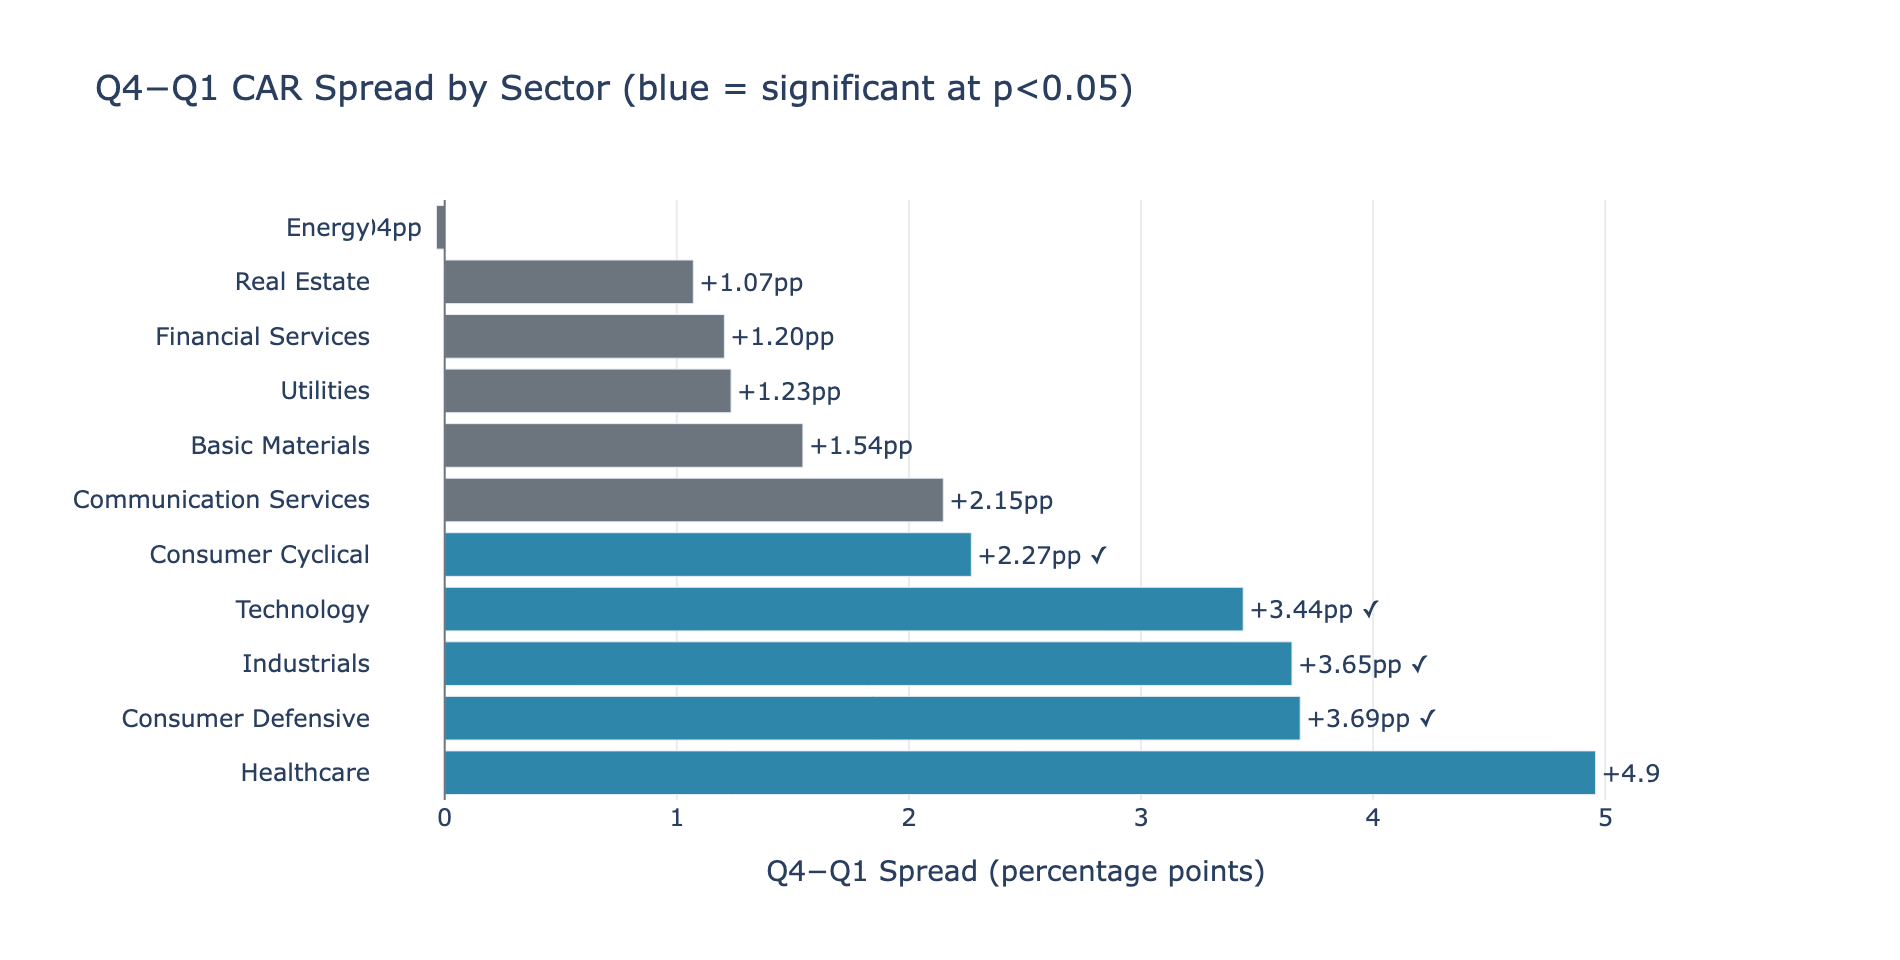

  Q4−Q1 CAR spread by sector. Blue bars are significant at p<0.05.


In [4]:
show("signal_sector_heatmap",
     "Q4−Q1 CAR spread by sector. Blue bars are significant at p<0.05.")


The signal is significant in **5 of 11 sectors**: Healthcare, Consumer Defensive,
Industrials, Technology, Consumer Cyclical. It is absent in sectors driven by
macro factors outside management control — Energy (commodity prices), Utilities
(rate expectations), Basic Materials, Financial Services (balance sheet metrics),
and Communication Services (mixed legacy/growth composition).


## Where the Signal Works and Where It Doesn't

**Strongest features** (survive Bonferroni in all regression specifications):
- `sentiment_delta` — QoQ tone change (primary signal, coef ≈ +0.11–0.12 across all windows)
- `analyst_tone` — sell-side questioning pressure (coef ≈ +0.06–0.07)
- `qa_divergence` — management defensiveness in Q&A vs prepared remarks (coef ≈ −0.01 to −0.02)

**Weakest features** (high multicollinearity with each other):
- `net_sentiment`, `sentiment_variance`, `negative_chunk_pct`, `ceo_sentiment`
  These were dropped from the primary regression after VIF > 5 was confirmed.
  Each is individually correlated with returns (r ≈ 0.04–0.12) but they measure
  the same underlying signal and cannot be jointly estimated.

**Regression R² ≈ 2%** — expected for individual-stock return prediction.
The sentiment features explain a small but statistically and economically meaningful
slice of post-earnings return variance.

## Limitations

1. **Survivorship bias** — 20.1% of events dropped due to missing price data.
   Excluded tickers have a median market cap of $1.1B vs $5.0B for retained names.
   Findings generalise to mid/large-cap equities; small-cap extrapolation is not supported.

2. **No earnings surprise control** — `sentiment_delta` may partly proxy for a
   genuine beat/miss. This is a plausible economic channel (management tone reflects
   results), not necessarily a confound — but the two signals cannot be separated
   without analyst consensus data.

3. **Transaction costs not modelled** — the Q4−Q1 spread is gross of bid-ask spread,
   market impact, and short-selling costs. A long/short strategy on earnings events
   would incur significant implementation costs, particularly in small-cap names.

4. **FinBERT domain fit** — the model was trained on financial news and analyst reports,
   not earnings call transcripts specifically. Procedural boilerplate is stripped by
   preprocessing, but domain mismatch may compress sentiment scores toward neutral
   relative to a transcript-fine-tuned model.

5. **2017–2018 coverage** — `sentiment_delta` requires a prior-quarter call, so
   effectively only 2019 onward has full signal coverage.
